### Variable Importance using Random Forests

Basic Idea: A random forest is trained on a dataset with d dimensional features. The drop in the test accuracy from the model predictions on the original dataset <br> and a dataset constructed by shuffling the k'th (0<=k<=d-1) feature across all test samples gives an indication of the importance of that feature.

This has been demonstrated for the breast cancer dataset on sklearn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_gaussian_quantiles, load_iris, load_breast_cancer
import os
import tqdm
from tqdm.auto import tqdm
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
%matplotlib inline
%config InlineBackend.figure_format = "svg"
pi = np.pi

In [2]:
data = load_breast_cancer();
X = data["data"]
y = data["target"]
class_names = data["target_names"]
feature_names = data["feature_names"]

In [7]:
class BinaryDecisionTree():
    class TreeNode():
        def __init__(self, X, y):
            self.X = X
            self.y = y
            self.feature = None
            self.threshold = None
            self.pmf = None
            self.entropy = None
            self.left = None
            self.right = None
            self.IG = None
            self.is_leaf = False
            self.depth = None
            
    def __init__(self,X,y, num_thresholds, min_leaf):
        num_features = X.shape[1]
        labels = set(y)
        num_classes = len(labels)
        self.X = X
        self.y = y
        self.num_thresholds = num_thresholds
        self.min_leaf = min_leaf
        self.num_features = num_features
        self.num_classes = num_classes
        self.root = None
        self.num_nodes = 1
        self.num_leaves = 0
        
    def get_pmf_entropy(self,y):
        num_classes = self.num_classes
        labels = range(num_classes)
        pmf = np.zeros(num_classes)
        for i in range(num_classes):
            pmf[i] = len(y[y==labels[i]])
        pmf = pmf/len(y)
        entropy = 0
        for p in pmf:
            if p!=0:
                entropy += -p*np.log2(p)

        return pmf,entropy
        
    def split_node(self,node):
        X = node.X
        y = node.y
        min_features = X.min(axis = 0)
        max_features = X.max(axis = 0)
        num_thresholds,num_features = self.num_thresholds,self.num_features
        thresholds = np.zeros((num_thresholds,num_features))
        for i in range(num_features):
            thresholds[:,i] = np.random.uniform(min_features[i], max_features[i],num_thresholds)
        
        IG = np.zeros((num_thresholds, num_features))
        num_samples = y.shape[0]
        pmf,entropy = node.pmf,node.entropy
        for i in range(num_features):
            for j in range(num_thresholds):
                threshold = thresholds[j,i]
                X_left = node.X[node.X[:,i]<threshold]
                y_left = node.y[node.X[:,i]<threshold]
                X_right = node.X[node.X[:,i]>=threshold]
                y_right = node.y[node.X[:,i]>=threshold]
                num_left = y_left.shape[0]
                p_left = num_left/num_samples
                p_right = 1 - p_left
                _,entropy_left = self.get_pmf_entropy(y_left)
                _,entropy_right = self.get_pmf_entropy(y_right)
                IG[j,i] = entropy - (entropy_left*p_left + entropy_right*p_right)
    
        ind = np.unravel_index(np.argmax(IG, axis=None), IG.shape)  
        optimum_threshold = thresholds[ind]
        optimum_feature = ind[1]
        optimum_IG = IG[ind]
        
        X_left = X[X[:,optimum_feature]<optimum_threshold]
        y_left = y[X[:,optimum_feature]<optimum_threshold]
        X_right = X[X[:,optimum_feature]>=optimum_threshold]
        y_right = y[X[:,optimum_feature]>=optimum_threshold]
    
        results = {"pmf":pmf,
                   "entropy":entropy,
                   "optimum_threshold":optimum_threshold,
                   "optimum_feature":optimum_feature,
                   "IG":optimum_IG,
                   "X_left":X_left,
                   "X_right":X_right,
                   "y_left":y_left,
                   "y_right":y_right
                  }
        
        return results

    def train_tree_helper(self, node, depth):
        X = node.X
        y = node.y
        node.depth = depth
        pmf,entropy = self.get_pmf_entropy(y)
        node.pmf = pmf
        node.entropy = entropy
        num_samples = X.shape[0]
        if num_samples <= self.min_leaf or node.entropy == 0:
            node.is_leaf = True
            self.num_leaves+=1
            return
        results = self.split_node(node)
        X_left = results["X_left"]
        X_right = results["X_right"]
        y_left = results["y_left"]
        y_right = results["y_right"]
        node.threshold = results["optimum_threshold"]
        node.feature = results["optimum_feature"]
        node.left = self.TreeNode(X_left,y_left)
        node.right = self.TreeNode(X_right, y_right)
        
        node.IG = results["IG"]
        self.num_nodes+=2
        self.train_tree_helper(node.left, depth+1)
        self.train_tree_helper(node.right, depth+1)
        
    def train_tree(self):
        X_train = self.X
        y_train = self.y
        self.root = self.TreeNode(X_train,y_train)
        self.train_tree_helper(self.root,0)

    def display_tree_helper(self,node):
        labels = list(np.arange(self.num_classes))
        if node is None:
            return
        if not node.is_leaf:
            IG = node.IG
            feature = node.feature
            threshold = node.threshold
            print(f"Depth: {node.depth} | x[{feature}]<{threshold:.2f}? | IG : {IG:.3f} | Entropy: {node.entropy:.3f}")
            self.display_tree_helper(node.left)
            self.display_tree_helper(node.right)
        else:
            pmf = node.pmf
            print(f"Depth: {node.depth} | Leaf Node | Entropy : {node.entropy:.3f} | Distribution : {node.pmf}")
            # plt.figure()
            # plt.bar(labels, pmf, color = colors[0:self.num_classes])
            # plt.title(f"Leaf node")
            # plt.show()

    def display_tree(self):
        node = self.root
        self.display_tree_helper(node)
        
    def infer_tree(self,X):
        preds = []
        if len(X.shape)==1:
            X = np.expand_dims(X, axis = 0)
            
        for sample in X:
            node = self.root
            pmf = None
            while True:
                if node.is_leaf:
                    preds.append(np.argmax(node.pmf))
                    pmf = node.pmf
                    break
                feature = node.feature
                threshold = node.threshold
                # print(f"Sample in tree: {sample}")
                # print(f"feature: {feature}")
                # print(f"threshold: {threshold}")
                if sample[feature]<threshold:
                    node = node.left
                else:
                    node = node.right

        preds = np.array(preds)
        return preds,pmf

In [8]:
class RandomForest():
    def __init__(self,X,y,num_trees, num_thresholds, min_leaf):
        num_features = X.shape[1]
        labels = set(y)
        num_classes = len(labels)
        self.X = X
        self.y = y
        self.num_thresholds = num_thresholds
        self.min_leaf = min_leaf
        self.num_features = num_features
        self.num_classes = num_classes
        self.num_trees = num_trees
        self.X_bootstrap = None
        self.y_bootstrap = None
        self.trees = []
        
    def train_forest(self):
        self.data_bootstrap()
        for i in range(self.num_trees):
            Xi,yi = self.X_bootstrap[i], self.y_bootstrap[i]
            tree = BinaryDecisionTree(Xi,yi,self.num_thresholds, self.min_leaf)
            tree.train_tree()
            self.trees.append(tree)

    def get_pmf_entropy(self,y):
        num_classes = self.num_classes
        labels = range(num_classes)
        pmf = np.zeros(num_classes)
        for i in range(num_classes):
            pmf[i] = len(y[y==labels[i]])
        pmf = pmf/len(y)
        entropy = 0
        for p in pmf:
            if p!=0:
                entropy += -p*np.log2(p)

        return pmf,entropy
    
    def display_bootstrap(self):
        labels = list(np.arange(self.num_classes))
        pmf,entropy = self.get_pmf_entropy(self.y)
        plt.figure()
        plt.bar(labels,pmf,color = colors[0:self.num_classes])
        plt.title(f"Original Dataset Entropy: {entropy:.3f}")
        plt.show()
        for i in range(self.num_trees):
            y = self.y_bootstrap[i]
            pmf,entropy = self.get_pmf_entropy(y)
            plt.figure()
            plt.bar(labels,pmf,color = colors[0:self.num_classes])
            plt.title(f"Bag {i} Entropy: {entropy:.3f}")
            plt.show()
        
    
    def data_bootstrap(self):
        X_bootstrap = {}
        y_bootstrap = {}
        num_trees, num_classes = self.num_trees, self.num_classes
        for i in range(num_trees):
            X_bootstrap[i] = []
            y_bootstrap[i] = []
    
        for i in range(num_classes):
            Xi = self.X[self.y==i]
            Ni = Xi.shape[0]
            assignment = np.random.choice(np.arange(num_trees),size = Ni)
            for j in range(Ni):
                X_bootstrap[assignment[j]].append(Xi[j])
                y_bootstrap[assignment[j]].append(i)

        for i in range(num_trees):
            X_bootstrap[i] = np.stack(X_bootstrap[i])
            y_bootstrap[i] = np.array(y_bootstrap[i])

        self.X_bootstrap = X_bootstrap
        self.y_bootstrap = y_bootstrap
            
    def infer_forest(self,X):
        preds = []
        for sample in X:
            # print(f"Sample in forest: {sample}")
            pmf = np.zeros((self.num_classes))
            pred = 0.0
            for tree in self.trees:
                _,p = tree.infer_tree(sample)
                pmf = pmf + p
            pmf/=self.num_trees
            pred = np.argmax(pmf)
            preds.append(pred)
            
        preds = np.array(preds)
        return preds

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y, train_size = 0.7, shuffle = True)
num_thresholds = 5
min_leaf = 20
Tree = BinaryDecisionTree(X_train,y_train,num_thresholds, min_leaf)
Tree.train_tree()
y_pred,_ = Tree.infer_tree(X_test)
test_accuracy = np.sum(y_pred==y_test)/len(y_test)
y_pred,_ = Tree.infer_tree(X_train)
train_accuracy = np.sum(y_pred==y_train)/len(y_train)
print(f"Training Accuracy : {train_accuracy*100:.3f}%")
print(f"Testing Accuracy : {test_accuracy*100:.3f}%")
print(f"Tree has {Tree.num_nodes} nodes")
print(f"Tree has {Tree.num_leaves} leaves")
# Tree.display_tree()

Training Accuracy : 96.482%
Testing Accuracy : 93.567%
Tree has 25 nodes
Tree has 13 leaves


In [20]:
X_train.shape, y_train.shape

((398, 30), (398,))

In [13]:
num_thresholds = 10
min_leaf = 10
num_trees = 3
Forest = RandomForest(X_train,y_train,num_trees,num_thresholds, min_leaf)
Forest.train_forest()
y_pred = Forest.infer_forest(X_test)
accuracy = np.sum(y_pred==y_test)/len(y_test)
print(f"Testing Accuracy : {accuracy*100:.3f}%")

Testing Accuracy : 96.491%


  0%|          | 0/1000 [00:00<?, ?it/s]

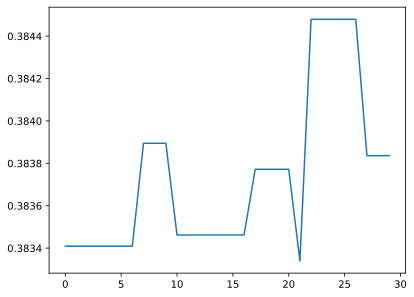

In [14]:
num_training_samples, num_features = X_train.shape
num_testing_samples = X_test.shape[0]
num_thresholds = 40
num_average = 1000;
min_leaf = 20
Tree = BinaryDecisionTree(X_train,y_train,num_thresholds, min_leaf)
Tree.train_tree()
y_pred,_ = Tree.infer_tree(X_test)
base_accuracy = np.sum(y_pred==y_test)/len(y_test)
importance = np.zeros((num_features))
avg_importance = np.zeros((num_features))
for j in tqdm(range(num_average)):
    for i in range(num_features):
        X_copy = X_test
        idx = np.random.permutation(num_testing_samples)
        X_copy[:,i] = X_test[idx,i]
        y_pred,_ = Tree.infer_tree(X_copy)
        test_accuracy = np.sum(y_pred==y_test)/len(y_test)
        importance[i] = (base_accuracy - test_accuracy)
    avg_importance = avg_importance + importance;

importance = avg_importance/num_average;
plt.plot(importance);

  0%|          | 0/200 [00:00<?, ?it/s]

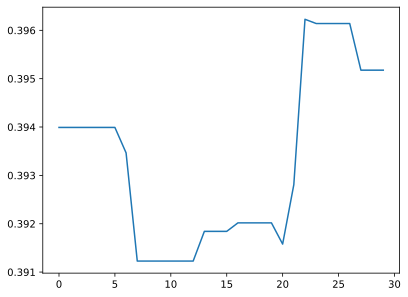

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y, train_size = 0.8, shuffle = True)
num_training_samples, num_features = X_train.shape
num_testing_samples = X_test.shape[0]
num_thresholds = 10
min_leaf = 10
num_trees = 2
Forest = RandomForest(X_train,y_train,num_trees,num_thresholds, min_leaf)
Forest.train_forest()
y_pred = Forest.infer_forest(X_test)
base_accuracy = np.sum(y_pred==y_test)/len(y_test)
num_average = 200;
importance = np.zeros((num_features))
avg_importance = np.zeros((num_features))
for j in tqdm(range(num_average)):
    for i in range(num_features):
        X_copy = X_test
        idx = np.random.permutation(num_testing_samples)
        X_copy[:,i] = X_test[idx,i]
        y_pred = Forest.infer_forest(X_copy)
        test_accuracy = np.sum(y_pred==y_test)/len(y_test)
        importance[i] = (base_accuracy - test_accuracy)
    avg_importance = avg_importance + importance;

importance = avg_importance/num_average;
plt.plot(importance);

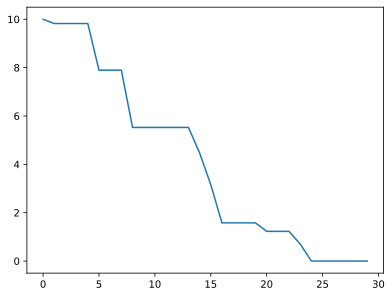

In [17]:
# Zip the feature names and their importance together
paired = list(zip(importance, feature_names))
# Sort the pairs based on importance in descending order
sorted_pairs = sorted(paired, reverse=True, key=lambda x: x[0])
# Extract the sorted feature names
sorted_feature_names = [name for imp, name in sorted_pairs]
# Extract the sorted importance (optional)
sorted_importance = [imp for imp, name in sorted_pairs]
min_importance = min(sorted_importance)
max_importance = max(sorted_importance)
normalized_importance = [(imp - min_importance) / (max_importance - min_importance) * 10 for imp in sorted_importance]

df = pd.DataFrame({
    'Feature Name': sorted_feature_names,
    'Importance': normalized_importance
})

plt.plot(normalized_importance);

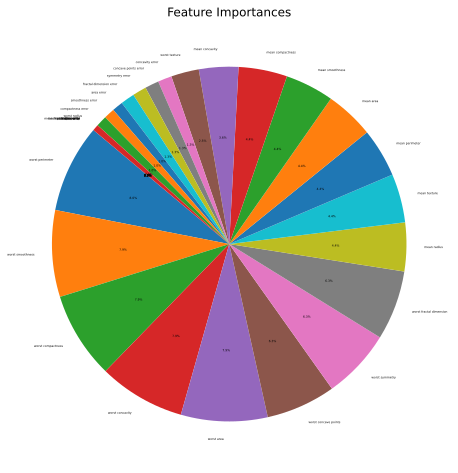

In [18]:
plt.figure(figsize=(8, 8))
plt.pie(df['Importance'], labels=df['Feature Name'], autopct='%1.1f%%', startangle=140,textprops={'fontsize': 3})
plt.title('Feature Importances')
plt.show()